# FL vs SFL — Non-IID One-Label-per-Client, 3-Layer Model

This notebook compares **Federated Learning (FL)** and **Split Federated Learning (SFL / Design 1)** on Fashion-MNIST under an extreme non-IID setting.

**Non-IID setup:** each client receives data from only one label. With Fashion-MNIST, this notebook uses **10 clients** so that labels 0–9 are all represented.

The model architecture is a 3-layer MLP:

```text
Full FL model: 784 -> 256 -> 128 -> 10
SFL client:    28*28 -> 256
SFL server:    256 -> 128 -> 10
```

The split happens after the first hidden layer, so the client has **1 trainable layer** and the server has **2 trainable layers**.

In [2]:
NOTEBOOK_ID = "05_FMNIST"

import os

# --------------------------------------------------
# Project/output folders
# --------------------------------------------------
# This notebook is normally run from the notebooks/ folder.
# If the current working directory is notebooks/, outputs are saved one level above it:
#     project_root/results/...
#     project_root/weights/...
# If the notebook is run from the project root instead, outputs are saved in that project root.
CURRENT_DIR = os.path.abspath(os.getcwd())
if os.path.basename(CURRENT_DIR).lower() == "notebooks":
    PROJECT_ROOT = os.path.dirname(CURRENT_DIR)
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_DIR = os.path.join(PROJECT_ROOT, "data")

RESULTS_DIR = os.path.join(PROJECT_ROOT, "results")
CSV_DIR = os.path.join(RESULTS_DIR, "csv", NOTEBOOK_ID)
PLOTS_DIR = os.path.join(RESULTS_DIR, "plots", NOTEBOOK_ID)

WEIGHTS_DIR = os.path.join(PROJECT_ROOT, "weights", NOTEBOOK_ID)
FL_WEIGHTS_DIR = os.path.join(WEIGHTS_DIR, "fl")
SFL_WEIGHTS_DIR = os.path.join(WEIGHTS_DIR, "sfl")

# In the corrected SFL structure, there are two separate aggregation domains:
#   1) client-side FL aggregation for the client-owned layer(s)
#   2) SFL server-side aggregation for the server-owned layer(s)
# The reconstructed full SFL model is saved only for evaluation/plotting, not as a deployed global model.
SFL_CLIENT_FL_WEIGHTS_DIR = os.path.join(SFL_WEIGHTS_DIR, "client_side_fl_aggregator")
SFL_SERVER_WEIGHTS_DIR = os.path.join(SFL_WEIGHTS_DIR, "sfl_server_aggregator")
SFL_EVAL_WEIGHTS_DIR = os.path.join(SFL_WEIGHTS_DIR, "evaluation_reconstructed_only")

for folder in [
    DATA_DIR,
    CSV_DIR,
    PLOTS_DIR,
    FL_WEIGHTS_DIR,
    SFL_CLIENT_FL_WEIGHTS_DIR,
    SFL_SERVER_WEIGHTS_DIR,
    SFL_EVAL_WEIGHTS_DIR,
]:
    os.makedirs(folder, exist_ok=True)

print("CURRENT_DIR:", CURRENT_DIR)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("CSV_DIR:", CSV_DIR)
print("PLOTS_DIR:", PLOTS_DIR)
print("FL_WEIGHTS_DIR:", FL_WEIGHTS_DIR)
print("SFL_WEIGHTS_DIR:", SFL_WEIGHTS_DIR)
print("SFL_CLIENT_FL_WEIGHTS_DIR:", SFL_CLIENT_FL_WEIGHTS_DIR)
print("SFL_SERVER_WEIGHTS_DIR:", SFL_SERVER_WEIGHTS_DIR)
print("SFL_EVAL_WEIGHTS_DIR:", SFL_EVAL_WEIGHTS_DIR)


CURRENT_DIR: /home/raed/Documents/Masters_project_SFL_servers/notebooks
PROJECT_ROOT: /home/raed/Documents/Masters_project_SFL_servers
DATA_DIR: /home/raed/Documents/Masters_project_SFL_servers/data
CSV_DIR: /home/raed/Documents/Masters_project_SFL_servers/results/csv/05_FMNIST
PLOTS_DIR: /home/raed/Documents/Masters_project_SFL_servers/results/plots/05_FMNIST
FL_WEIGHTS_DIR: /home/raed/Documents/Masters_project_SFL_servers/weights/05_FMNIST/fl
SFL_WEIGHTS_DIR: /home/raed/Documents/Masters_project_SFL_servers/weights/05_FMNIST/sfl
SFL_CLIENT_FL_WEIGHTS_DIR: /home/raed/Documents/Masters_project_SFL_servers/weights/05_FMNIST/sfl/client_side_fl_aggregator
SFL_SERVER_WEIGHTS_DIR: /home/raed/Documents/Masters_project_SFL_servers/weights/05_FMNIST/sfl/sfl_server_aggregator
SFL_EVAL_WEIGHTS_DIR: /home/raed/Documents/Masters_project_SFL_servers/weights/05_FMNIST/sfl/evaluation_reconstructed_only


## Updated model used in this version

This notebook uses a split-compatible **3-layer MLP**:

```text
Full FL model: 784 -> 256 -> 128 -> 10
SFL client:    28*28 -> 256
SFL server:    256 -> 128 -> 10
```

This gives the requested SFL structure:

- **Client side:** 1 trainable layer
- **Server side:** 2 trainable layers
- **FL model:** same complete 3-layer model on every client

The split happens after the first hidden layer. The client produces the cut-layer activation, also called smashed data, and the server completes the forward and backward pass.

## Learning-rate update

This version uses the 3-layer architecture and the corrected separated SFL aggregation structure:

```text
Full model:   784 -> 256 -> 128 -> 10
SFL client:   784 -> 256
SFL server:   256 -> 128 -> 10
```

The notebook uses a round-level learning rate schedule with initial learning rate 0.04:

```python
INITIAL_LR = 0.04
LR_DECAY = 1.0
current_lr = INITIAL_LR * LR_DECAY ** (round_id - 1)
```

There is still no gradient clipping, no momentum, no BatchNorm, and no Adam. This keeps the FL/SFL equivalence check cleaner.

Corrected SFL aggregation structure:

```text
Client-side layer(s): aggregated by the client-side FL aggregator
Server-side layer(s): aggregated by the SFL server aggregator
Reconstructed full model: used only for evaluation/plotting
```


## Diagnostic note: why the one-label non-IID accuracy may not improve

This notebook uses the most extreme label-skew setting: **10 clients and each client receives only one Fashion-MNIST class**.

That means:

- client 0 only trains on class 0
- client 1 only trains on class 1
- ...
- client 9 only trains on class 9

Although all labels exist globally, each local optimisation step is based on only one class. This can cause **client drift**: each client update strongly pushes the model toward its own class. When FedAvg averages these highly biased updates, the global model may remain close to random guessing, especially with a deeper model, small number of rounds, and conservative learning-rate decay.

Notebook 02 may behave differently because it uses a different FL implementation/model structure and different hyperparameters. In particular, notebook 02 uses a simpler `TwoNN` model and may use different learning rate, local epochs, and experiment settings. Notebook 05 is stricter because it is trying to make FL and SFL mathematically equivalent, so it uses the same starting model, deterministic client loaders, and compares FL and SFL global states using L2 distance.


In [3]:
import os
import copy
import time
import random
from collections import OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

## 1. Reproducibility and device setup

In [4]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


SEED = 42
set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## 2. Experiment settings and output folders

Run this notebook from the repository root folder: `Masters_project_SFL_servers/`.

In [5]:
# Fashion-MNIST has 10 labels, so using 10 clients gives one label per client and still covers all classes.
NUM_CLIENTS = 10
ROUNDS = 100
LOCAL_EPOCHS = 1
BATCH_SIZE = 64
TEST_BATCH_SIZE = 256

# Set to an integer such as 1000 for a quick test run.
# Set to None for the full one-label-per-client dataset.
MAX_SAMPLES_PER_CLIENT = None

print("CSV results will be saved to:", CSV_DIR)
print("Plots will be saved to:", PLOTS_DIR)
print("Weights will be saved to:", WEIGHTS_DIR)

# --------------------------------------------------
# Learning rate
# --------------------------------------------------
# Mild round-level LR decay for the 784 -> 256 -> 128 -> 64 -> 10 architecture.
# INITIAL_LR and LR_DECAY are defined only once in this notebook.
# The decay is applied once per communication round in the main training loop.
INITIAL_LR = 0.04
LR_DECAY = 0.995

def get_round_lr(round_id):
    """
    Return the learning rate for the current communication round.

    Example:
        round 1   -> 0.040000
        round 100 -> 0.04 * (0.995 ** 99)
    """
    return INITIAL_LR * (LR_DECAY ** (round_id - 1))


CSV results will be saved to: /home/raed/Documents/Masters_project_SFL_servers/results/csv/05_FMNIST
Plots will be saved to: /home/raed/Documents/Masters_project_SFL_servers/results/plots/05_FMNIST
Weights will be saved to: /home/raed/Documents/Masters_project_SFL_servers/weights/05_FMNIST


## 3. Load Fashion-MNIST dataset

In [6]:
transform = transforms.ToTensor()

# Fashion-MNIST images are grayscale with shape [1, 28, 28].
# The model flattens each image to 28 * 28 = 784 input features.

train_dataset = datasets.FashionMNIST(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.FashionMNIST(
    root=DATA_DIR,
    train=False,
    download=True,
    transform=transform,
)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

Train samples: 60000
Test samples: 10000


## 4. Create non-IID client datasets

Each client receives samples from only one label.

Example: client 1 gets label 0, client 2 gets label 1, ..., client 10 gets label 9.

In [7]:
def get_targets(dataset):
    if hasattr(dataset, "targets"):
        targets = dataset.targets
        if torch.is_tensor(targets):
            targets = targets.cpu().numpy()
        return np.array(targets)
    return np.array([dataset[i][1] for i in range(len(dataset))])


def create_one_label_client_subsets(dataset, num_clients: int, seed: int, max_samples_per_client=None):
    targets = get_targets(dataset)
    unique_labels = sorted(np.unique(targets).tolist())

    if num_clients > len(unique_labels):
        raise ValueError("num_clients cannot be greater than the number of labels for one-label-per-client setup.")

    selected_labels = unique_labels[:num_clients]
    rng = np.random.default_rng(seed)

    subsets = []
    client_label_map = {}

    for client_id, label in enumerate(selected_labels):
        label_indices = np.where(targets == label)[0]
        rng.shuffle(label_indices)

        if max_samples_per_client is not None:
            label_indices = label_indices[:max_samples_per_client]

        subsets.append(Subset(dataset, label_indices.tolist()))
        client_label_map[client_id] = label

    return subsets, client_label_map


client_subsets, client_label_map = create_one_label_client_subsets(
    train_dataset,
    num_clients=NUM_CLIENTS,
    seed=SEED,
    max_samples_per_client=MAX_SAMPLES_PER_CLIENT,
)

for client_id, subset in enumerate(client_subsets):
    print(f"Client {client_id + 1}: label={client_label_map[client_id]}, samples={len(subset)}")

sample_counts = [len(subset) for subset in client_subsets]
print("Total samples used:", sum(sample_counts))

Client 1: label=0, samples=6000
Client 2: label=1, samples=6000
Client 3: label=2, samples=6000
Client 4: label=3, samples=6000
Client 5: label=4, samples=6000
Client 6: label=5, samples=6000
Client 7: label=6, samples=6000
Client 8: label=7, samples=6000
Client 9: label=8, samples=6000
Client 10: label=9, samples=6000
Total samples used: 60000


## 5. Data loaders

FL and SFL use the same deterministic batch order for each client and round.

In [8]:
def make_client_loader(client_id: int, round_id: int, method_tag: str):
    # Same seed formula for FL and SFL ensures identical batch order.
    loader_seed = SEED + round_id * 1000 + client_id
    generator = torch.Generator().manual_seed(loader_seed)

    return DataLoader(
        client_subsets[client_id],
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=generator,
    )


test_loader = DataLoader(
    test_dataset,
    batch_size=TEST_BATCH_SIZE,
    shuffle=False,
)

## 6. Models

In [9]:
from collections import OrderedDict

class FullModel(nn.Module):
    """
    Full FL model for notebook 05.

    Three-layer MLP architecture:
        Flatten
        fc1: 784 -> 256
        ReLU
        fc2: 256 -> 128
        ReLU
        fc3: 128 -> 10

    SFL split:
        Client side: fc1 + ReLU
        Server side: fc2 + ReLU + fc3
    """

    def __init__(self, input_dim=28 * 28, hidden_dim1=256, hidden_dim2=128, num_classes=10):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(input_dim, hidden_dim1)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim1, hidden_dim2)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden_dim2, num_classes)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        return self.fc3(x)


class ClientModel(nn.Module):
    """
    SFL client-side model.

    Contains:
        Flatten -> fc1 -> ReLU

    The cut-layer activation has shape [batch_size, 256].
    """

    def __init__(self, input_dim=28 * 28, hidden_dim1=256):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(input_dim, hidden_dim1)
        self.relu1 = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        return self.relu1(self.fc1(x))


class ServerModel(nn.Module):
    """
    SFL server-side model.

    Contains:
        fc2: 256 -> 128
        ReLU
        fc3: 128 -> 10
    """

    def __init__(self, hidden_dim1=256, hidden_dim2=128, num_classes=10):
        super().__init__()
        self.fc2 = nn.Linear(hidden_dim1, hidden_dim2)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden_dim2, num_classes)

    def forward(self, x):
        x = self.relu2(self.fc2(x))
        return self.fc3(x)


## 7. State dictionary helpers

In [10]:
def get_state_dict(model: nn.Module):
    return OrderedDict((k, v.detach().cpu().clone()) for k, v in model.state_dict().items())


def load_state_dict_to_model(model: nn.Module, state_dict):
    model.load_state_dict(state_dict, strict=True)


def full_to_client_state(full_state):
    """
    Extract the client-side part of the full 3-layer model.

    Split used in this notebook:
        Client side: fc1
        Server side: fc2 + fc3
    """
    return OrderedDict({
        "fc1.weight": full_state["fc1.weight"].clone(),
        "fc1.bias": full_state["fc1.bias"].clone(),
    })


def full_to_server_state(full_state):
    """
    Extract the server-side part of the full 3-layer model.

    Split used in this notebook:
        Client side: fc1
        Server side: fc2 + fc3
    """
    return OrderedDict({
        "fc2.weight": full_state["fc2.weight"].clone(),
        "fc2.bias": full_state["fc2.bias"].clone(),
        "fc3.weight": full_state["fc3.weight"].clone(),
        "fc3.bias": full_state["fc3.bias"].clone(),
    })


def split_to_full_state(client_state, server_state):
    """
    Reconstruct the full 3-layer FL model from the SFL client and server states.

    Full model: fc1 + fc2 + fc3.
    """
    return OrderedDict({
        "fc1.weight": client_state["fc1.weight"].clone(),
        "fc1.bias": client_state["fc1.bias"].clone(),
        "fc2.weight": server_state["fc2.weight"].clone(),
        "fc2.bias": server_state["fc2.bias"].clone(),
        "fc3.weight": server_state["fc3.weight"].clone(),
        "fc3.bias": server_state["fc3.bias"].clone(),
    })


def fedavg_state_dicts(state_dicts, sample_counts):
    total_samples = sum(sample_counts)
    avg_state = OrderedDict()

    for key in state_dicts[0].keys():
        avg_state[key] = sum(
            state_dicts[i][key] * (sample_counts[i] / total_samples)
            for i in range(len(state_dicts))
        )

    return avg_state


def l2_distance_between_states(state_a, state_b):
    squared_sum = 0.0
    for key in state_a.keys():
        diff = state_a[key].float() - state_b[key].float()
        squared_sum += torch.sum(diff * diff).item()
    return squared_sum ** 0.5


def aggregate_client_layers_with_fl_server(client_side_states, sample_counts):
    """
    Aggregate only the client-owned SFL layer(s) using the client-side FL aggregator.

    This wrapper intentionally calls FedAvg, but its name makes the architecture clear:
    these weights belong to the client-side FL aggregation domain, not to the SFL server.
    """
    return fedavg_state_dicts(client_side_states, sample_counts)


def aggregate_server_layers_with_sfl_server(server_side_states, sample_counts):
    """
    Aggregate only the server-owned SFL layer(s) using the SFL server-side aggregator.

    This wrapper intentionally calls FedAvg, but its name makes the architecture clear:
    these weights belong to the SFL server aggregation domain.
    """
    return fedavg_state_dicts(server_side_states, sample_counts)

# ============================================================
# L2 distance between two state_dict objects
# ============================================================
def l2_distance_state_dicts(state_a, state_b):
    """
    Compute the Euclidean/L2 distance between two model state_dicts.

    This is used only as an experimental metric to compare the reconstructed
    SFL global model against the standard FL global model. It does not imply
    that a real SFL server holds the full model in deployment.
    """
    total = 0.0

    for key in state_a.keys():
        if key in state_b:
            diff = state_a[key].float() - state_b[key].float()
            total += torch.sum(diff * diff).item()

    return total ** 0.5


## 8. Evaluation function

In [11]:
@torch.no_grad()
def evaluate_model(model: nn.Module, loader: DataLoader, device: torch.device):
    model.eval()
    criterion = nn.CrossEntropyLoss()

    total_loss = 0.0
    correct = 0
    total = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * y.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    return total_loss / total, correct / total

## 9. FL client training

In [12]:
def train_fl_client(start_global_state, train_loader: DataLoader, local_epochs: int, lr: float, device: torch.device):
    model = FullModel().to(device)
    load_state_dict_to_model(model, start_global_state)

    model.train()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)

    for _ in range(local_epochs):
        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

    return get_state_dict(model)

## 10. SFL Design 1 client training

Each client trains a client-side copy and an independent server-side copy for that round. Then both parts are aggregated with FedAvg.

In [13]:
def train_sfl_client_design1(start_client_state, start_server_state, train_loader: DataLoader, local_epochs: int, lr: float, device: torch.device):
    client_model = ClientModel().to(device)
    server_model = ServerModel().to(device)

    load_state_dict_to_model(client_model, start_client_state)
    load_state_dict_to_model(server_model, start_server_state)

    client_model.train()
    server_model.train()

    criterion = nn.CrossEntropyLoss()
    client_optimizer = optim.SGD(client_model.parameters(), lr=lr)
    server_optimizer = optim.SGD(server_model.parameters(), lr=lr)

    for _ in range(local_epochs):
        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            client_optimizer.zero_grad()
            server_optimizer.zero_grad()

            smashed_data = client_model(x)
            smashed_data_detached = smashed_data.detach().requires_grad_(True)

            logits = server_model(smashed_data_detached)
            loss = criterion(logits, y)
            loss.backward()

            grad_to_client = smashed_data_detached.grad.clone()
            server_optimizer.step()

            smashed_data.backward(grad_to_client)
            client_optimizer.step()

    return get_state_dict(client_model), get_state_dict(server_model)

## 11. Initialise FL and SFL from identical weights

In [14]:
set_seed(SEED)
initial_full_model = FullModel()
initial_full_state = get_state_dict(initial_full_model)

fl_global_state = copy.deepcopy(initial_full_state)
# SFL client-side global state belongs to the separate FL aggregation domain.
sfl_client_fl_global_state = full_to_client_state(initial_full_state)

# SFL server-side global state belongs to the SFL server aggregation domain.
sfl_server_global_state = full_to_server_state(initial_full_state)

print("Initial FL and SFL states prepared from the same full model.")

# Sanity check: the client and server states must contain the expected split layers.
print("SFL client-side FL aggregator keys:", list(sfl_client_fl_global_state.keys()))
print("SFL server-side aggregator keys:", list(sfl_server_global_state.keys()))
assert "fc1.weight" in sfl_client_fl_global_state
assert "fc2.weight" in sfl_server_global_state and "fc3.weight" in sfl_server_global_state


Initial FL and SFL states prepared from the same full model.
SFL client-side FL aggregator keys: ['fc1.weight', 'fc1.bias']
SFL server-side aggregator keys: ['fc2.weight', 'fc2.bias', 'fc3.weight', 'fc3.bias']


## 12. Run 100 rounds and evaluate global accuracy after every round


In [15]:
results = []

for round_id in range(1, ROUNDS + 1):

    # get_round_lr() is called here once per communication round.
    # The same current_lr is then passed to every FL and SFL client in this round.
    current_lr = get_round_lr(round_id)
    print(f"Learning rate this round: {current_lr:.6f}")
    print(f"\n========== Round {round_id}/{ROUNDS} ==========")
    round_start_time = time.perf_counter()

    # -------------------------
    # FL local training
    # -------------------------
    fl_start_time = time.perf_counter()
    fl_client_states = []

    for client_id in range(NUM_CLIENTS):
        loader = make_client_loader(client_id, round_id, method_tag="fl")
        trained_state = train_fl_client(
            start_global_state=fl_global_state,
            train_loader=loader,
            local_epochs=LOCAL_EPOCHS,
            lr=current_lr,
            device=device,
        )
        fl_client_states.append(trained_state)

    fl_global_state = fedavg_state_dicts(fl_client_states, sample_counts)
    fl_time = time.perf_counter() - fl_start_time

    # Save only global model every round to avoid too many files.
    torch.save(fl_global_state, os.path.join(FL_WEIGHTS_DIR, f"fl_round_{round_id:03d}_global.pth"))

    # -------------------------
    # SFL local training with separated aggregators
    # -------------------------
    sfl_start_time = time.perf_counter()
    sfl_client_side_states = []
    sfl_server_side_states = []

    for client_id in range(NUM_CLIENTS):
        loader = make_client_loader(client_id, round_id, method_tag="sfl")
        trained_client_state, trained_server_state = train_sfl_client_design1(
            start_client_state=sfl_client_fl_global_state,
            start_server_state=sfl_server_global_state,
            train_loader=loader,
            local_epochs=LOCAL_EPOCHS,
            lr=current_lr,
            device=device,
        )
        sfl_client_side_states.append(trained_client_state)
        sfl_server_side_states.append(trained_server_state)

    # Client-owned SFL layer(s) are aggregated by the client-side FL aggregator.
    # The SFL server should not directly see or aggregate these client-side weights.
    sfl_client_fl_global_state = aggregate_client_layers_with_fl_server(
        sfl_client_side_states,
        sample_counts,
    )

    # Server-owned SFL layer(s) are aggregated by the SFL server-side aggregator.
    sfl_server_global_state = aggregate_server_layers_with_sfl_server(
        sfl_server_side_states,
        sample_counts,
    )

    # Reconstruct a full model only for evaluation and comparison with FL.
    # This is not a deployed object in the corrected SFL architecture.
    sfl_global_full_state = split_to_full_state(
        sfl_client_fl_global_state,
        sfl_server_global_state,
    )
    sfl_time = time.perf_counter() - sfl_start_time

    torch.save(
        sfl_client_fl_global_state,
        os.path.join(SFL_CLIENT_FL_WEIGHTS_DIR, f"sfl_round_{round_id:03d}_client_side_fl_global.pth"),
    )
    torch.save(
        sfl_server_global_state,
        os.path.join(SFL_SERVER_WEIGHTS_DIR, f"sfl_round_{round_id:03d}_sfl_server_global.pth"),
    )
    torch.save(
        sfl_global_full_state,
        os.path.join(SFL_EVAL_WEIGHTS_DIR, f"sfl_round_{round_id:03d}_full_reconstructed_for_eval_only.pth"),
    )

    # -------------------------
    # Evaluate global models after aggregation
    # -------------------------
    eval_start_time = time.perf_counter()

    fl_eval_model = FullModel().to(device)
    load_state_dict_to_model(fl_eval_model, fl_global_state)
    fl_test_loss, fl_test_acc = evaluate_model(fl_eval_model, test_loader, device)

    sfl_eval_model = FullModel().to(device)
    load_state_dict_to_model(sfl_eval_model, sfl_global_full_state)
    sfl_test_loss, sfl_test_acc = evaluate_model(sfl_eval_model, test_loader, device)

    eval_time = time.perf_counter() - eval_start_time
    total_round_time = time.perf_counter() - round_start_time

    global_l2 = l2_distance_state_dicts(fl_global_state, sfl_global_full_state)

    results.append({
        "round": round_id,
        "fl_test_loss": fl_test_loss,
        "fl_test_accuracy": fl_test_acc,
        "sfl_test_loss": sfl_test_loss,
        "sfl_test_accuracy": sfl_test_acc,
        "fl_minus_sfl_accuracy": fl_test_acc - sfl_test_acc,
        "global_l2_distance_fl_vs_sfl": global_l2,
        "fl_time_sec": fl_time,
        "sfl_time_sec": sfl_time,
        "evaluation_time_sec": eval_time,
        "total_round_time_sec": total_round_time,
    })

    print(
        f"Round {round_id:03d} | "
        f"FL acc={fl_test_acc:.4f}, SFL acc={sfl_test_acc:.4f}, "
        f"L2={global_l2:.6f}, "
        f"FL time={fl_time:.1f}s, SFL time={sfl_time:.1f}s"
    )

results_df = pd.DataFrame(results)
display(results_df)



Learning rate this round: 0.040000

========== Round 1/100 ==========
Round 001 | FL acc=0.1169, SFL acc=0.1169, L2=0.000000, FL time=2.8s, SFL time=3.0s
Learning rate this round: 0.039800

========== Round 2/100 ==========
Round 002 | FL acc=0.2032, SFL acc=0.2032, L2=0.000000, FL time=2.7s, SFL time=2.9s
Learning rate this round: 0.039601

========== Round 3/100 ==========
Round 003 | FL acc=0.1014, SFL acc=0.1014, L2=0.000000, FL time=2.5s, SFL time=3.1s
Learning rate this round: 0.039403

========== Round 4/100 ==========
Round 004 | FL acc=0.1805, SFL acc=0.1805, L2=0.000000, FL time=3.3s, SFL time=3.3s
Learning rate this round: 0.039206

========== Round 5/100 ==========
Round 005 | FL acc=0.2371, SFL acc=0.2371, L2=0.000000, FL time=3.0s, SFL time=3.2s
Learning rate this round: 0.039010

========== Round 6/100 ==========
Round 006 | FL acc=0.2115, SFL acc=0.2115, L2=0.000000, FL time=2.6s, SFL time=2.8s
Learning rate this round: 0.038815

========== Round 7/100 ==========
Round 

,round,fl_test_loss,fl_test_accuracy,sfl_test_loss,sfl_test_accuracy,fl_minus_sfl_accuracy,global_l2_distance_fl_vs_sfl,fl_time_sec,sfl_time_sec,evaluation_time_sec,total_round_time_sec
0,1,2.305052,0.1169,2.305052,0.1169,0.0,0.0,2.825246,3.021156,0.488401,6.343376
1,2,2.319291,0.2032,2.319291,0.2032,0.0,0.0,2.730922,2.892933,0.584784,6.215827
2,3,2.277150,0.1014,2.277150,0.1014,0.0,0.0,2.519946,3.068452,0.597052,6.187890
3,4,2.207306,0.1805,2.207306,0.1805,0.0,0.0,3.323120,3.266547,0.616756,7.209147
4,5,2.171418,0.2371,2.171418,0.2371,0.0,0.0,3.035114,3.171662,0.595105,6.805824
...,...,...,...,...,...,...,...,...,...,...,...
95,96,1.257062,0.5647,1.257062,0.5647,0.0,0.0,2.500622,2.702838,0.575431,5.786486
96,97,1.286727,0.6485,1.286727,0.6485,0.0,0.0,2.680747,2.689572,0.567107,5.940238
97,98,1.243576,0.5723,1.243576,0.5723,0.0,0.0,2.346510,2.555146,0.575476,5.479753
98,99,1.275814,0.6342,1.275814,0.6342,0.0,0.0,2.727035,2.890190,0.564645,6.184380


## 13. Save CSV results

In [16]:
results_csv_path = os.path.join(CSV_DIR, f"fl_vs_sfl_noniid_one_label_{ROUNDS}_rounds.csv")
results_df.to_csv(results_csv_path, index=False)
print("Saved results CSV to:", results_csv_path)


Saved results CSV to: /home/raed/Documents/Masters_project_SFL_servers/results/csv/05_FMNIST/fl_vs_sfl_noniid_one_label_100_rounds.csv


## 14. Plot FL vs SFL accuracy

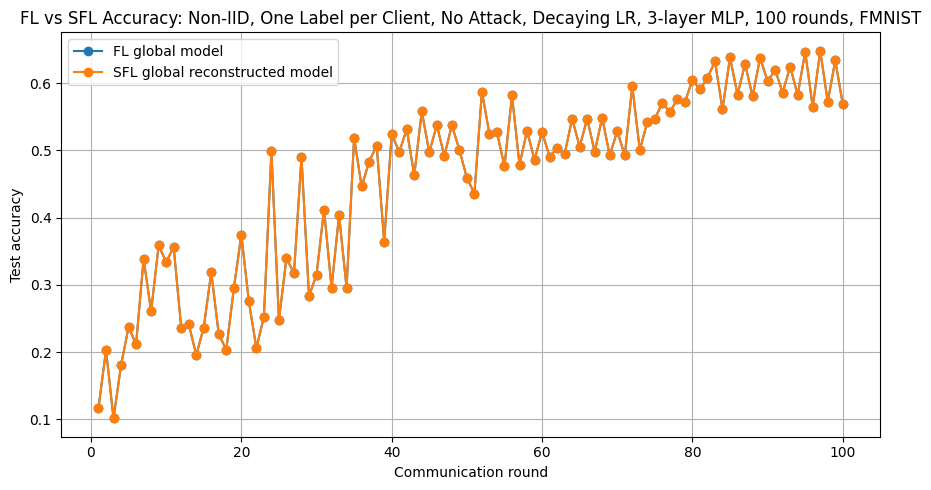

Saved accuracy plot to: /home/raed/Documents/Masters_project_SFL_servers/results/plots/05_FMNIST/fl_vs_sfl_noniid_one_label_accuracy_100_rounds.png


In [17]:
accuracy_plot_path = os.path.join(PLOTS_DIR, f"fl_vs_sfl_noniid_one_label_accuracy_{ROUNDS}_rounds.png")

plt.figure(figsize=(9, 5))
plt.plot(results_df["round"], results_df["fl_test_accuracy"], marker="o", label="FL global model")
plt.plot(results_df["round"], results_df["sfl_test_accuracy"], marker="o", label="SFL global reconstructed model")
plt.xlabel("Communication round")
plt.ylabel("Test accuracy")
plt.title("FL vs SFL Accuracy: Non-IID, One Label per Client, No Attack, Decaying LR, 3-layer MLP, 100 rounds, FMNIST")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(accuracy_plot_path, dpi=200)
plt.show()

print("Saved accuracy plot to:", accuracy_plot_path)


## 15. Plot FL vs SFL loss

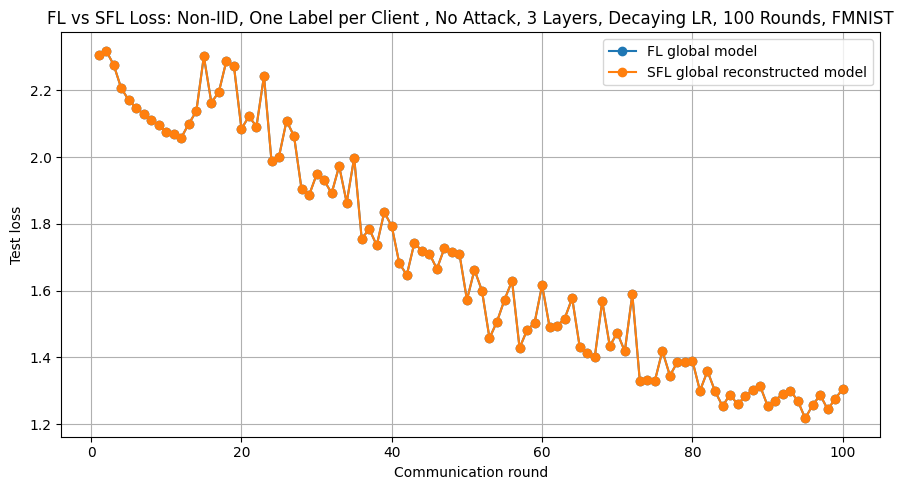

Saved loss plot to: /home/raed/Documents/Masters_project_SFL_servers/results/plots/05_FMNIST/fl_vs_sfl_noniid_one_label_loss_100_rounds.png


In [18]:
loss_plot_path = os.path.join(PLOTS_DIR, f"fl_vs_sfl_noniid_one_label_loss_{ROUNDS}_rounds.png")

plt.figure(figsize=(9, 5))
plt.plot(results_df["round"], results_df["fl_test_loss"], marker="o", label="FL global model")
plt.plot(results_df["round"], results_df["sfl_test_loss"], marker="o", label="SFL global reconstructed model")
plt.xlabel("Communication round")
plt.ylabel("Test loss")
plt.title("FL vs SFL Loss: Non-IID, One Label per Client , No Attack, 3 Layers, Decaying LR, 100 Rounds, FMNIST")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(loss_plot_path, dpi=200)
plt.show()

print("Saved loss plot to:", loss_plot_path)


## 16. Short report text for README / thesis notes

In [19]:
summary_text = f"""
Experiment: FL vs SFL under extreme non-IID data distribution.

Architecture: 784 -> 256 -> 128 -> 10, split as client 28*28 -> 256 and server 256 -> 128 -> 10.
Dataset: Fashion-MNIST.
Clients: {NUM_CLIENTS}.
Non-IID setting: each client receives data from only one label/class.
Communication rounds: {ROUNDS}.
Local epochs per client per round: {LOCAL_EPOCHS}.
SFL client-side layers are aggregated by the client-side FL aggregator.
SFL server-side layers are aggregated by the SFL server-side aggregator.

The FL global model and the evaluation-only reconstructed SFL model were evaluated after every aggregation round on the full Fashion-MNIST test set.
The final FL accuracy was {results_df['fl_test_accuracy'].iloc[-1]:.4f}.
The final SFL accuracy was {results_df['sfl_test_accuracy'].iloc[-1]:.4f}.

The saved CSV file contains one row per communication round, giving {ROUNDS} accuracy values for FL and {ROUNDS} accuracy values for SFL.
"""

summary_path = os.path.join(CSV_DIR, f"fl_vs_sfl_noniid_one_label_summary_{ROUNDS}_rounds.txt")
with open(summary_path, "w", encoding="utf-8") as f:
    f.write(summary_text)

print(summary_text)
print("Saved summary text to:", summary_path)



Experiment: FL vs SFL under extreme non-IID data distribution.

Architecture: 784 -> 256 -> 128 -> 10, split as client 28*28 -> 256 and server 256 -> 128 -> 10.
Dataset: Fashion-MNIST.
Clients: 10.
Non-IID setting: each client receives data from only one label/class.
Communication rounds: 100.
Local epochs per client per round: 1.
SFL client-side layers are aggregated by the client-side FL aggregator.
SFL server-side layers are aggregated by the SFL server-side aggregator.

The FL global model and the evaluation-only reconstructed SFL model were evaluated after every aggregation round on the full Fashion-MNIST test set.
The final FL accuracy was 0.5687.
The final SFL accuracy was 0.5687.

The saved CSV file contains one row per communication round, giving 100 accuracy values for FL and 100 accuracy values for SFL.

Saved summary text to: /home/raed/Documents/Masters_project_SFL_servers/results/csv/05_FMNIST/fl_vs_sfl_noniid_one_label_summary_100_rounds.txt


## Comparison with the earlier 5-layer and 2-layer notebooks

This version uses a 3-layer fully connected network:

```text
Full FL model: 784 -> 256 -> 128 -> 10
SFL client:    28*28 -> 256
SFL server:    256 -> 128 -> 10
```

Why this version is useful:

1. **It keeps SFL meaningful**  
   The client has one trainable layer and the server has two trainable layers.

2. **It is simpler than the 5-layer model**  
   The previous 5-layer MLP was very unstable under one-label-per-client non-IID training.

3. **It gives more server-side depth than the 2-layer model**  
   The earlier 2-layer model had only one server-side layer. This version gives the server a deeper role while remaining easier to train than the 5-layer model.

4. **It keeps FL/SFL architecture aligned**  
   The FL-only clients train the same complete 3-layer model that is reconstructed from the SFL client and server states.

Recommended next checks:

- Watch whether the L2 distance remains close to zero.
- Compare the accuracy curve against the 2-layer and 5-layer versions.
- If accuracy collapses again, reduce `INITIAL_LR` from `0.01` to `0.005` before adding any stabilization tricks.
